## 📦 Cell 1 — Install & Import

In [1]:
!pip install xgboost lightgbm optuna --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, copy

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier, VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
print('✅ All libraries loaded!')

'pip' is not recognized as an internal or external command,
operable program or batch file.


✅ All libraries loaded!


## 📂 Cell 2 — Load Data

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')
test_ids = test['PassengerId'].copy()

print(f'Train: {train.shape} | Test: {test.shape}')
print(f'Survival rate: {train["Survived"].mean():.3f}')
print('\nMissing values:')
print(train.isnull().sum()[train.isnull().sum() > 0])
train.head()

Train: (891, 12) | Test: (418, 11)
Survival rate: 0.384

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🔑 Cell 3 — LOO Group Survival Features

**This is the biggest score booster.** Passengers on the same ticket or same family name travel together and have correlated survival. We encode this using Leave-One-Out mean encoding to avoid label leakage.

In [3]:
GLOBAL_SURV = train['Survived'].mean()  # ~0.384

train['LastName'] = train['Name'].str.split(',').str[0]
test['LastName']  = test['Name'].str.split(',').str[0]

def compute_loo_feature(df_train, df_test, group_col, target_col='Survived', global_mean=GLOBAL_SURV):
    """
    Leave-One-Out mean encoding:
    - Train: for each row, use the mean of all OTHER rows in its group
    - Test:  use the full group mean from train
    This avoids leaking the row's own label.
    """
    train_out = np.full(len(df_train), global_mean)
    groups = df_train.groupby(group_col)
    for _, grp in groups:
        group_sum   = grp[target_col].sum()
        group_count = len(grp)
        for idx in grp.index:
            rest_cnt = group_count - 1
            if rest_cnt > 0:
                train_out[idx] = (group_sum - grp.loc[idx, target_col]) / rest_cnt
            else:
                train_out[idx] = global_mean

    full_mean_map = df_train.groupby(group_col)[target_col].mean()
    test_out = df_test[group_col].map(full_mean_map).fillna(global_mean).values
    return train_out, test_out

# Ticket group LOO
train_ticket_loo, test_ticket_loo = compute_loo_feature(train, test, 'Ticket')
# Family name LOO
train_family_loo, test_family_loo = compute_loo_feature(train, test, 'LastName')

print(f'Ticket LOO — train range: [{train_ticket_loo.min():.2f}, {train_ticket_loo.max():.2f}]')
print(f'Family LOO — train range: [{train_family_loo.min():.2f}, {train_family_loo.max():.2f}]')
print('✅ LOO features computed (leak-safe)')

Ticket LOO — train range: [0.00, 1.00]
Family LOO — train range: [0.00, 1.00]
✅ LOO features computed (leak-safe)


## ⚙️ Cell 4 — Feature Engineering

In [4]:
full = pd.concat([train, test], axis=0, ignore_index=True)

def engineer_features(df):
    df = df.copy()

    # ── Title ─────────────────────────────────────────────────────────
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
    rare = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(rare, 'Rare')

    # ── Age — multi-level fallback imputation ──────────────────────────
    global_age_med  = df['Age'].median()
    age_by_tp = df.groupby(['Title','Pclass'])['Age'].median()
    age_by_p  = df.groupby('Pclass')['Age'].median()
    def fill_age(row):
        if pd.isna(row['Age']):
            k = (row['Title'], row['Pclass'])
            if k in age_by_tp.index and not pd.isna(age_by_tp[k]):
                return age_by_tp[k]
            return age_by_p.get(row['Pclass'], global_age_med)
        return row['Age']
    df['Age'] = df.apply(fill_age, axis=1).fillna(global_age_med)

    # ── Fare ──────────────────────────────────────────────────────────
    df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    # ── Embarked ──────────────────────────────────────────────────────
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # ── Cabin ──────────────────────────────────────────────────────────
    df['Has_Cabin']  = df['Cabin'].notna().astype(int)
    df['Cabin_Deck'] = df['Cabin'].str[0].fillna('Unknown')

    # ── Family ────────────────────────────────────────────────────────
    df['FamilySize']  = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']     = (df['FamilySize'] == 1).astype(int)
    df['SmallFamily'] = ((df['FamilySize'] >= 2) & (df['FamilySize'] <= 4)).astype(int)
    df['LargeFamily'] = (df['FamilySize'] >= 5).astype(int)

    # ── Ticket ────────────────────────────────────────────────────────
    df['Ticket_Freq'] = df.groupby('Ticket')['Ticket'].transform('count')

    # ── Fare features ─────────────────────────────────────────────────
    df['LogFare']        = np.log1p(df['Fare'])
    df['FareBin']        = pd.qcut(df['Fare'], 5, labels=False, duplicates='drop').astype(float)
    df['Fare_PerPerson'] = df['Fare'] / df['Ticket_Freq'].clip(lower=1)
    df['LogFare_Per']    = np.log1p(df['Fare_PerPerson'])

    # ── Age features ──────────────────────────────────────────────────
    df['AgeBin']    = pd.cut(df['Age'], bins=[0,5,12,18,35,60,120], labels=[0,1,2,3,4,5]).astype(float)
    df['IsChild']   = (df['Age'] < 16).astype(int)
    df['IsSenior']  = (df['Age'] > 60).astype(int)

    # ── Gender ────────────────────────────────────────────────────────
    df['IsWoman']     = (df['Sex'] == 'female').astype(int)
    df['WomanOrChild']= ((df['Sex'] == 'female') | (df['Age'] < 16)).astype(int)
    df['IsMother']    = ((df['Sex']=='female') & (df['Age']>18) &
                         (df['Parch']>0) & (df['Title']!='Miss')).astype(int)

    # ── Sex × Pclass dummies (most powerful interaction) ──────────────
    df['Female_P1'] = ((df['Sex']=='female') & (df['Pclass']==1)).astype(int)
    df['Female_P2'] = ((df['Sex']=='female') & (df['Pclass']==2)).astype(int)
    df['Female_P3'] = ((df['Sex']=='female') & (df['Pclass']==3)).astype(int)
    df['Male_P1']   = ((df['Sex']=='male')   & (df['Pclass']==1)).astype(int)
    df['Male_P2']   = ((df['Sex']=='male')   & (df['Pclass']==2)).astype(int)
    df['Male_P3']   = ((df['Sex']=='male')   & (df['Pclass']==3)).astype(int)

    # ── Other interactions ────────────────────────────────────────────
    df['Age_Pclass']  = df['Age'] * df['Pclass']
    df['Fare_Pclass'] = df['LogFare'] / df['Pclass']
    df['Age_x_Fare']  = df['Age'] * df['LogFare']
    df['NameLength']  = df['Name'].apply(len)

    return df

full_fe = engineer_features(full)
print(f'✅ Features engineered. Total columns: {full_fe.shape[1]}')

✅ Features engineered. Total columns: 41


## 🔢 Cell 5 — Encode & Build Final Feature Matrix

In [5]:
cat_cols = ['Title', 'Cabin_Deck', 'Embarked', 'Sex']
le = LabelEncoder()
for col in cat_cols:
    full_fe[col] = le.fit_transform(full_fe[col].astype(str))

drop_cols = ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin', 'LastName']
feature_cols = [c for c in full_fe.columns if c not in drop_cols]

train_fe = full_fe[full_fe['Survived'].notna()].reset_index(drop=True)
test_fe  = full_fe[full_fe['Survived'].isna()].reset_index(drop=True)

train_median = train_fe[feature_cols].astype(float).median()

X      = train_fe[feature_cols].astype(float).fillna(train_median)
y      = train_fe['Survived'].astype(int)
X_test = test_fe[feature_cols].astype(float).fillna(train_median)

# ── Add LOO group survival features (from Cell 3) ────────────────────
X['Ticket_SurvRate'] = train_ticket_loo
X['Family_SurvRate'] = train_family_loo
X_test['Ticket_SurvRate'] = test_ticket_loo
X_test['Family_SurvRate'] = test_family_loo

# ✅ Final NaN check
assert X.isnull().sum().sum() == 0,      '❌ NaN in X!'
assert X_test.isnull().sum().sum() == 0, '❌ NaN in X_test!'

print(f'✅ X:      {X.shape}')
print(f'✅ X_test: {X_test.shape}')
print(f'✅ Zero NaN confirmed')
print(f'\nAll features ({len(X.columns)}):')
print(list(X.columns))

✅ X:      (891, 37)
✅ X_test: (418, 37)
✅ Zero NaN confirmed

All features (37):
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'Has_Cabin', 'Cabin_Deck', 'FamilySize', 'IsAlone', 'SmallFamily', 'LargeFamily', 'Ticket_Freq', 'LogFare', 'FareBin', 'Fare_PerPerson', 'LogFare_Per', 'AgeBin', 'IsChild', 'IsSenior', 'IsWoman', 'WomanOrChild', 'IsMother', 'Female_P1', 'Female_P2', 'Female_P3', 'Male_P1', 'Male_P2', 'Male_P3', 'Age_Pclass', 'Fare_Pclass', 'Age_x_Fare', 'NameLength', 'Ticket_SurvRate', 'Family_SurvRate']


## 📊 Cell 6 — Feature Importance

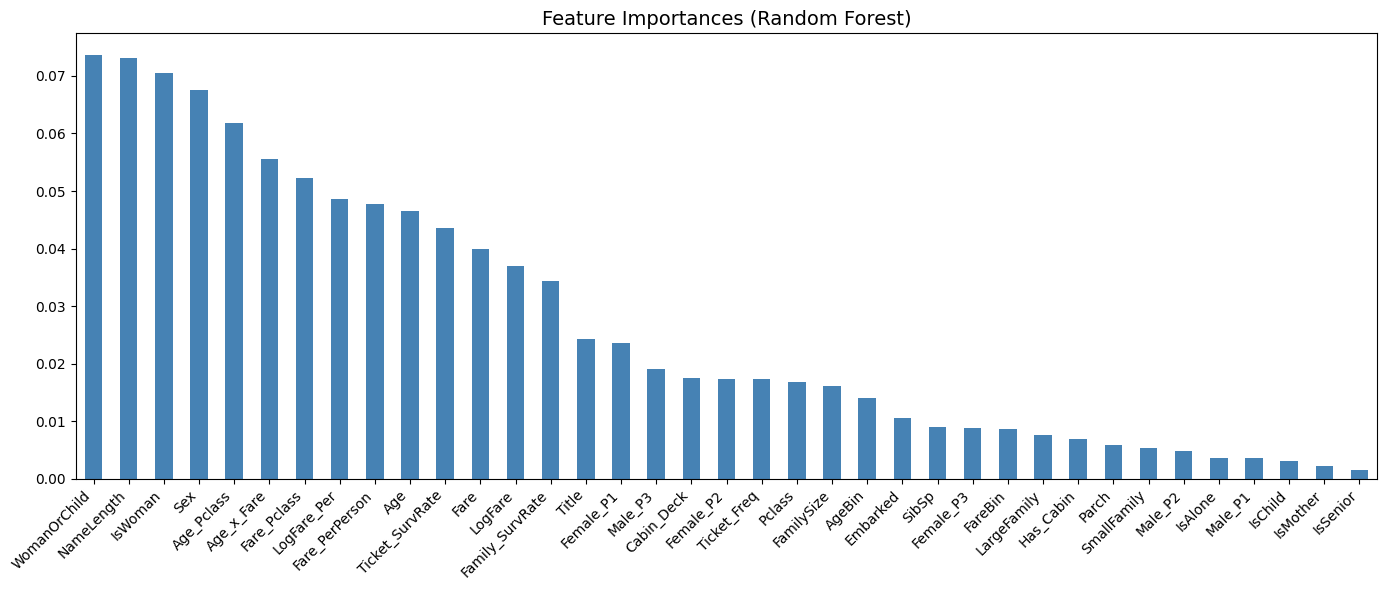

Top 12 features:
  WomanOrChild          : 0.0737
  NameLength            : 0.0731
  IsWoman               : 0.0705
  Sex                   : 0.0676
  Age_Pclass            : 0.0618
  Age_x_Fare            : 0.0556
  Fare_Pclass           : 0.0523
  LogFare_Per           : 0.0486
  Fare_PerPerson        : 0.0478
  Age                   : 0.0465
  Ticket_SurvRate       : 0.0435
  Fare                  : 0.0399


In [6]:
rf_check = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_check.fit(X, y)

feat_imp = pd.Series(rf_check.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
feat_imp.plot.bar(color='steelblue')
plt.title('Feature Importances (Random Forest)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 12 features:')
for f, v in feat_imp.head(12).items():
    print(f'  {f:<22}: {v:.4f}')

## 🎯 Cell 7 — Optuna Tuning: XGBoost

In [7]:
CV = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric':      'logloss',
        'tree_method':      'hist',
        'random_state':     SEED,
    }
    model = xgb.XGBClassifier(**params)
    return cross_val_score(model, X, y, cv=CV, scoring='accuracy', n_jobs=-1).mean()

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=60, show_progress_bar=True)
print(f'\n✅ XGBoost best CV: {xgb_study.best_value:.5f}')
print(xgb_study.best_params)

Best trial: 41. Best value: 0.856317: 100%|████████████████████████████████████████████████| 60/60 [00:13<00:00,  4.56it/s]


✅ XGBoost best CV: 0.85632
{'n_estimators': 539, 'max_depth': 4, 'learning_rate': 0.017243406180192725, 'subsample': 0.6959867790410925, 'colsample_bytree': 0.8273375549421723, 'min_child_weight': 7, 'gamma': 0.6715433759514574, 'reg_alpha': 1.852588488590778e-05, 'reg_lambda': 0.05048777697228396}


## 🎯 Cell 8 — Optuna Tuning: LightGBM

In [8]:
def lgb_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state':      SEED,
        'verbose':           -1
    }
    model = lgb.LGBMClassifier(**params)
    return cross_val_score(model, X, y, cv=CV, scoring='accuracy', n_jobs=-1).mean()

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=60, show_progress_bar=True)
print(f'\n✅ LightGBM best CV: {lgb_study.best_value:.5f}')
print(lgb_study.best_params)

Best trial: 24. Best value: 0.848439: 100%|████████████████████████████████████████████████| 60/60 [00:54<00:00,  1.11it/s]


✅ LightGBM best CV: 0.84844
{'n_estimators': 177, 'max_depth': 5, 'learning_rate': 0.029764535115785862, 'num_leaves': 100, 'subsample': 0.712098751129556, 'colsample_bytree': 0.7090628079379544, 'min_child_samples': 67, 'reg_alpha': 2.70244627595447e-06, 'reg_lambda': 0.03053976195592396}


## 🧱 Cell 9 — Define All Models

In [9]:
best_xgb_params = {**xgb_study.best_params,
                   'eval_metric':'logloss', 'tree_method':'hist', 'random_state':SEED}
best_lgb_params = {**lgb_study.best_params, 'random_state':SEED, 'verbose':-1}

scaler        = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# Each entry: (model, X_train_array, X_test_array)
models = {
    'XGBoost':  (xgb.XGBClassifier(**best_xgb_params),
                 X.values, X_test.values),

    'LightGBM': (lgb.LGBMClassifier(**best_lgb_params),
                 X.values, X_test.values),

    'RandomForest': (RandomForestClassifier(
                        n_estimators=600, max_depth=8,
                        min_samples_leaf=2, max_features='sqrt',
                        random_state=SEED, n_jobs=-1),
                     X.values, X_test.values),

    'ExtraTrees': (ExtraTreesClassifier(
                        n_estimators=600, max_depth=8,
                        min_samples_leaf=2,
                        random_state=SEED, n_jobs=-1),
                   X.values, X_test.values),

    'HistGBM':  (HistGradientBoostingClassifier(
                        max_iter=400, learning_rate=0.03,
                        max_depth=5, random_state=SEED),
                 X.values, X_test.values),

    'LogReg':   (LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
                 X_scaled, X_test_scaled),

    'SVM':      (SVC(C=1.0, kernel='rbf', probability=True, random_state=SEED),
                 X_scaled, X_test_scaled),
}

print('✅ Models ready:', list(models.keys()))

✅ Models ready: ['XGBoost', 'LightGBM', 'RandomForest', 'ExtraTrees', 'HistGBM', 'LogReg', 'SVM']


## 📊 Cell 10 — Cross-Validation Comparison

XGBoost         : 0.85632 ± 0.02799
LightGBM        : 0.84844 ± 0.01987
RandomForest    : 0.84958 ± 0.02219
ExtraTrees      : 0.84283 ± 0.02946
HistGBM         : 0.84059 ± 0.03264
LogReg          : 0.84511 ± 0.02509
SVM             : 0.84282 ± 0.03156

🏆 Best single: XGBoost — 0.85632


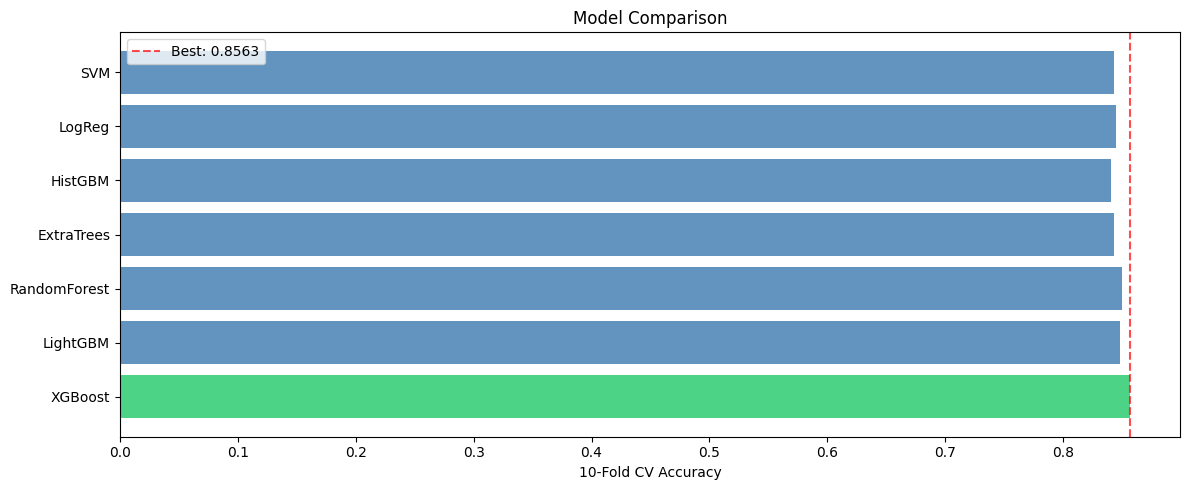

In [10]:
cv_results = {}
for name, (model, X_cv, _) in models.items():
    scores = cross_val_score(model, X_cv, y, cv=CV, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<16}: {scores.mean():.5f} ± {scores.std():.5f}')

best_single = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'\n🏆 Best single: {best_single} — {cv_results[best_single].mean():.5f}')

plt.figure(figsize=(12, 5))
means = [cv_results[m].mean() for m in models]
colors = ['#2ecc71' if m == best_single else 'steelblue' for m in models]
plt.barh(list(models.keys()), means, color=colors, alpha=0.85)
plt.axvline(max(means), color='red', linestyle='--', alpha=0.7, label=f'Best: {max(means):.4f}')
plt.xlabel('10-Fold CV Accuracy'); plt.title('Model Comparison')
plt.legend(); plt.tight_layout(); plt.show()

## 🏆 Cell 11 — Out-of-Fold Stacking

In [11]:
n_models  = len(models)
n_splits  = 10
oof_train = np.zeros((len(X), n_models))
oof_test  = np.zeros((len(X_test), n_models))
model_names = list(models.keys())

for i, (name, (model, X_use, X_test_use)) in enumerate(models.items()):
    test_folds = np.zeros((len(X_test), n_splits))
    for fold, (tr_idx, val_idx) in enumerate(CV.split(X_use, y)):
        m = copy.deepcopy(model)
        m.fit(X_use[tr_idx], y.iloc[tr_idx])
        oof_train[val_idx, i]   = m.predict_proba(X_use[val_idx])[:, 1]
        test_folds[:, fold]     = m.predict_proba(X_test_use)[:, 1]
    oof_test[:, i] = test_folds.mean(axis=1)
    acc = accuracy_score(y, (oof_train[:, i] > 0.5).astype(int))
    print(f'✅ {name:<16} OOF accuracy: {acc:.4f}')

print('\n✅ Stacking OOF complete!')

✅ XGBoost          OOF accuracy: 0.8530
✅ LightGBM         OOF accuracy: 0.8485
✅ RandomForest     OOF accuracy: 0.8496
✅ ExtraTrees       OOF accuracy: 0.8429
✅ HistGBM          OOF accuracy: 0.8406
✅ LogReg           OOF accuracy: 0.8451
✅ SVM              OOF accuracy: 0.8406

✅ Stacking OOF complete!


## 🧠 Cell 12 — Meta-Learner

In [12]:
meta = LogisticRegression(C=0.5, max_iter=1000, random_state=SEED)
meta_scores = cross_val_score(meta, oof_train, y, cv=CV, scoring='accuracy')
print(f'🏆 Stack CV accuracy: {meta_scores.mean():.5f} ± {meta_scores.std():.5f}')

meta.fit(oof_train, y)
stack_preds = meta.predict(oof_test)

print('\nMeta weights:')
for name, coef in zip(model_names, meta.coef_[0]):
    print(f'  {name:<16}: {coef:+.4f}')

🏆 Stack CV accuracy: 0.84396 ± 0.02347

Meta weights:
  XGBoost         : +0.7985
  LightGBM        : +0.6806
  RandomForest    : +1.2442
  ExtraTrees      : +1.3976
  HistGBM         : +0.1754
  LogReg          : +1.0273
  SVM             : +0.3772


## 🗳️ Cell 13 — Soft Voting Ensemble

In [13]:
voting_estimators = [
    ('xgb', copy.deepcopy(models['XGBoost'][0])),
    ('lgb', copy.deepcopy(models['LightGBM'][0])),
    ('rf',  copy.deepcopy(models['RandomForest'][0])),
    ('et',  copy.deepcopy(models['ExtraTrees'][0])),
    ('hgb', copy.deepcopy(models['HistGBM'][0])),
]
voting_clf = VotingClassifier(estimators=voting_estimators, voting='soft', n_jobs=-1)
voting_scores = cross_val_score(voting_clf, X.values, y, cv=CV, scoring='accuracy', n_jobs=-1)
print(f'🗳️ Voting CV accuracy: {voting_scores.mean():.5f} ± {voting_scores.std():.5f}')

voting_clf.fit(X.values, y)
voting_preds = voting_clf.predict(X_test.values)

🗳️ Voting CV accuracy: 0.84395 ± 0.02654


## 📁 Cell 14 — Select Best & Save Submission

In [14]:
stack_score  = meta_scores.mean()
voting_score = voting_scores.mean()
best_single_score = cv_results[best_single].mean()

print('='*50)
print(f'  Stacking Ensemble : {stack_score:.5f}')
print(f'  Soft Voting       : {voting_score:.5f}')
print(f'  Best Single       : {best_single_score:.5f}  ({best_single})')
print('='*50)

all_scores = [stack_score, voting_score, best_single_score]
best_overall = max(all_scores)

if best_overall == stack_score:
    final_preds = stack_preds
    method = 'Stacking Ensemble'
elif best_overall == voting_score:
    final_preds = voting_preds
    method = 'Soft Voting'
else:
    bm, bX, bX_test = models[best_single]
    bm_fit = copy.deepcopy(bm)
    bm_fit.fit(bX, y)
    final_preds = bm_fit.predict(bX_test)
    method = f'Best Single ({best_single})'

print(f'\n✅ Submitting with: {method}')
print(f'Predicted survival rate: {final_preds.mean():.3f}  (train baseline: {y.mean():.3f})')

submission = pd.DataFrame({'PassengerId': test_ids, 'Survived': final_preds.astype(int)})
submission.to_csv('submission.csv', index=False)
print('📁 submission.csv saved!')
submission.head(10)

  Stacking Ensemble : 0.84396
  Soft Voting       : 0.84395
  Best Single       : 0.85632  (XGBoost)

✅ Submitting with: Best Single (XGBoost)
Predicted survival rate: 0.359  (train baseline: 0.384)
📁 submission.csv saved!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


## 📈 Cell 15 — Evaluation & Confusion Matrix

=== OOF Evaluation ===
OOF Accuracy: 0.84400

              precision    recall  f1-score   support

        Died       0.85      0.91      0.88       549
    Survived       0.84      0.73      0.78       342

    accuracy                           0.84       891
   macro avg       0.84      0.82      0.83       891
weighted avg       0.84      0.84      0.84       891



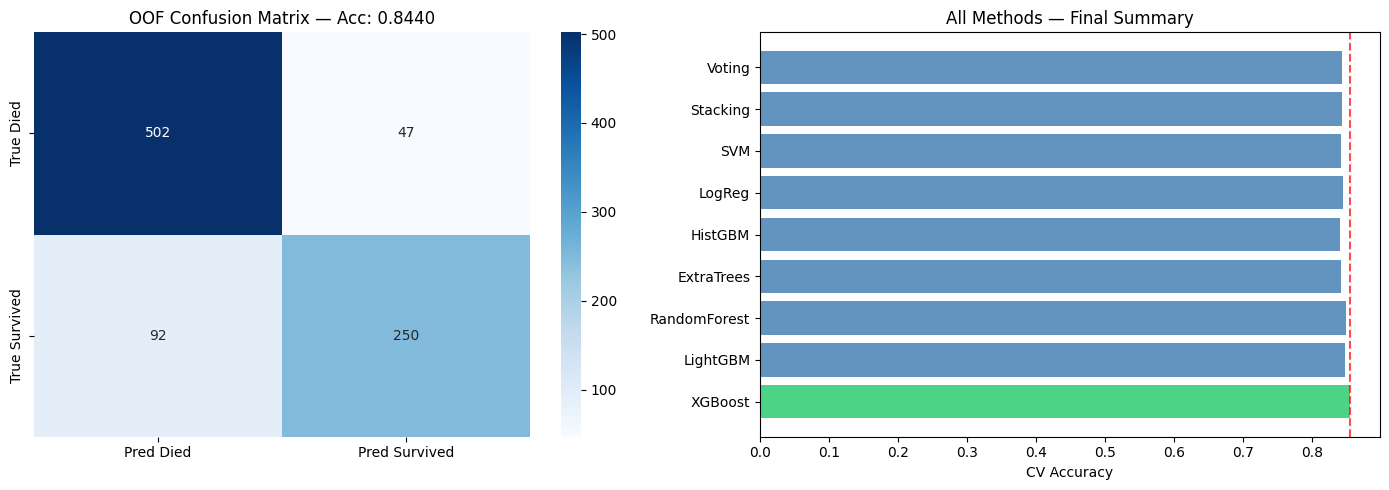

In [16]:
oof_pred = (meta.predict_proba(oof_train)[:, 1] > 0.5).astype(int)

print('=== OOF Evaluation ===')
print(f'OOF Accuracy: {accuracy_score(y, oof_pred):.5f}')
print()
print(classification_report(y, oof_pred, target_names=['Died','Survived']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y, oof_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Died','Pred Survived'],
            yticklabels=['True Died','True Survived'])
axes[0].set_title(f'OOF Confusion Matrix — Acc: {accuracy_score(y, oof_pred):.4f}')

all_cv = {**{k: v.mean() for k, v in cv_results.items()},
          'Stacking': stack_score, 'Voting': voting_score}
bar_colors = ['#2ecc71' if v == max(all_cv.values()) else 'steelblue' for v in all_cv.values()]
axes[1].barh(list(all_cv.keys()), list(all_cv.values()), color=bar_colors, alpha=0.85)
axes[1].axvline(max(all_cv.values()), color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('CV Accuracy'); axes[1].set_title('All Methods — Final Summary')

plt.tight_layout()
plt.show()